In [1]:
# On lit directement la table finale produite par dbt, pas de retransformation ici
from google.cloud import bigquery

client = bigquery.Client(project="finprev-portfolio")

query = """
SELECT *
FROM `finprev-portfolio.finprev.fct_client_monthly_features`
"""
df = client.query(query).to_dataframe()

print("Shape :", df.shape)
print()
print("Répartition de la cible :")
print(df["target_fragile_j3m"].value_counts(normalize=True).round(3))
df.head()

c:\Users\Moi\OneDrive\Bureau\financial-fragility-detection\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Shape : (30000, 15)

Répartition de la cible :
target_fragile_j3m
0    0.917
1    0.083
Name: proportion, dtype: Float64


,client_id,mois,age,statut_pro,anciennete_mois,revenus_entrants,revenus_entrants_lag1,revenus_entrants_delta,revenus_entrants_roll3,revenus_entrants_roll6,nb_incidents_roll3,nb_decouverts_roll3,ratio_charges_revenu,fragile_legal,target_fragile_j3m
0,CLI_00001,7,67,retraite,138,1514.59,1659.90,-145.31,1553.113333,1543.063333,1.333333,1.333333,0.375514,0,0
1,CLI_00001,11,67,retraite,138,1022.46,867.52,154.94,1067.000000,1325.080000,2.666667,1.333333,0.590488,1,0
2,CLI_00001,12,67,retraite,138,1254.69,1022.46,232.23,1048.223333,1257.545000,2.666667,1.666667,0.481195,1,0
3,CLI_00001,3,67,retraite,138,1317.59,1618.36,-300.77,1478.063333,1508.237500,0.000000,0.666667,0.405096,0,0
4,CLI_00001,14,67,retraite,138,1162.18,1053.41,108.77,1156.760000,1111.880000,2.000000,3.000000,0.519498,1,0


In [2]:
# On verifie d'abord l'etendue des mois disponibles
print("Mois min/max :", df["mois"].min(), df["mois"].max())
print()

# Split temporel : train sur les premiers mois, test sur les derniers
# Jamais de split aleatoire ici, pour respecter la logique metier
# (on ne doit jamais utiliser le futur pour predire le passe)
train_df = df[df["mois"] < 12].copy()
test_df = df[df["mois"] >= 12].copy()

print("Train shape :", train_df.shape)
print("Test shape :", test_df.shape)
print()
print("Taux positif train :", round(train_df["target_fragile_j3m"].mean(), 3))
print("Taux positif test :", round(test_df["target_fragile_j3m"].mean(), 3))

Mois min/max : 0 14

Train shape : (24000, 15)
Test shape : (6000, 15)

Taux positif train : 0.075
Taux positif test : 0.117


In [3]:
# Baseline par regles metier : un score simple, sans aucun apprentissage,
# construit uniquement a partir de seuils sur des features qu'on juge
# pertinents suite a l'EDA (ratio charges/revenus, incidents recents)
def score_regle_metier(row):
    score = 0
    if row["ratio_charges_revenu"] > 0.5:
        score += 1
    if row["nb_incidents_roll3"] > 1:
        score += 1
    if row["nb_decouverts_roll3"] > 1:
        score += 1
    if row["revenus_entrants_delta"] < -100:
        score += 1
    return score

test_df["score_baseline"] = test_df.apply(score_regle_metier, axis=1)

# On teste plusieurs seuils de decision pour voir lequel donne le meilleur equilibre
from sklearn.metrics import precision_score, recall_score, f1_score

print("Seuil | Recall | Precision | F1")
for seuil in range(0, 5):
    pred = (test_df["score_baseline"] >= seuil).astype(int)
    recall = recall_score(test_df["target_fragile_j3m"], pred)
    precision = precision_score(test_df["target_fragile_j3m"], pred, zero_division=0)
    f1 = f1_score(test_df["target_fragile_j3m"], pred, zero_division=0)
    print(f"{seuil}     | {recall:.3f}  | {precision:.3f}     | {f1:.3f}")

Seuil | Recall | Precision | F1
0     | 1.000  | 0.117     | 0.209
1     | 0.949  | 0.263     | 0.412
2     | 0.697  | 0.293     | 0.413
3     | 0.392  | 0.284     | 0.329
4     | 0.127  | 0.209     | 0.158


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Colonnes utilisees comme features : on exclut les identifiants et la cible,
# et surtout fragile_legal (qui decoule directement de la cible, fuite garantie)
feature_cols = [
    "age", "anciennete_mois",
    "revenus_entrants", "revenus_entrants_lag1", "revenus_entrants_delta",
    "revenus_entrants_roll3", "revenus_entrants_roll6",
    "nb_incidents_roll3", "nb_decouverts_roll3", "ratio_charges_revenu",
]

# Encodage du statut professionnel (categoriel)
train_encoded = pd.get_dummies(train_df, columns=["statut_pro"], prefix="statut", drop_first=True)
test_encoded = pd.get_dummies(test_df, columns=["statut_pro"], prefix="statut", drop_first=True)

statut_cols = [c for c in train_encoded.columns if c.startswith("statut_")]
all_features = feature_cols + statut_cols

# On aligne les colonnes au cas ou une categorie de statut serait absente d'un des deux jeux
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

X_train = train_encoded[all_features].fillna(0)
y_train = train_encoded["target_fragile_j3m"]
X_test = test_encoded[all_features].fillna(0)
y_test = test_encoded["target_fragile_j3m"]

# Standardisation necessaire pour la regression logistique
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# class_weight="balanced" compense le desequilibre des classes
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Recall :", round(recall_score(y_test, y_pred), 3))
print("Precision :", round(precision_score(y_test, y_pred), 3))
print("F1 :", round(f1_score(y_test, y_pred), 3))

Recall : 0.865
Precision : 0.332
F1 : 0.48


In [5]:
# Coefficients de la regression logistique : direction et poids de chaque feature
coefs = pd.DataFrame({
    "feature": all_features,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

print(coefs.to_string(index=False))

               feature  coefficient
revenus_entrants_roll3    -1.403023
   nb_decouverts_roll3     1.355180
revenus_entrants_roll6     0.939965
        statut_salarie     0.625850
    statut_independant     0.593599
      revenus_entrants    -0.463043
 revenus_entrants_lag1     0.189485
       statut_retraite     0.130588
revenus_entrants_delta     0.125774
    statut_sans_emploi    -0.043028
                   age     0.031612
    nb_incidents_roll3     0.021782
  ratio_charges_revenu     0.020892
       anciennete_mois    -0.015189


In [6]:
# Matrice de correlation entre les features numeriques,
# pour diagnostiquer la multicolinearite suspectee
corr_matrix = train_df[[
    "revenus_entrants", "revenus_entrants_lag1", "revenus_entrants_delta",
    "revenus_entrants_roll3", "revenus_entrants_roll6",
    "nb_incidents_roll3", "nb_decouverts_roll3", "ratio_charges_revenu"
]].corr().round(2)

print(corr_matrix)

                        revenus_entrants  revenus_entrants_lag1  \
revenus_entrants                    1.00                   0.86   
revenus_entrants_lag1               0.86                   1.00   
revenus_entrants_delta              0.27                  -0.26   
revenus_entrants_roll3              0.96                   0.96   
revenus_entrants_roll6              0.95                   0.95   
nb_incidents_roll3                 -0.46                  -0.47   
nb_decouverts_roll3                -0.48                  -0.48   
ratio_charges_revenu               -0.08                  -0.04   

                        revenus_entrants_delta  revenus_entrants_roll3  \
revenus_entrants                          0.27                    0.96   
revenus_entrants_lag1                    -0.26                    0.96   
revenus_entrants_delta                    1.00                    0.00   
revenus_entrants_roll3                    0.00                    1.00   
revenus_entrants_roll6    

In [7]:
# Le ratio est-il vraiment lie a la cible, tout court, sans passer par les autres features ?
print(train_df.groupby("target_fragile_j3m")["ratio_charges_revenu"].mean().round(3))
print()
print(train_df["ratio_charges_revenu"].describe().round(3))

target_fragile_j3m
0    0.386
1    0.719
Name: ratio_charges_revenu, dtype: float64

count    23989.000
mean         0.411
std          1.714
min          0.231
25%          0.343
50%          0.353
75%          0.372
max        261.789
Name: ratio_charges_revenu, dtype: float64


In [8]:
# 1. Recharger les donnees depuis BigQuery (avec le ratio corrige)
query = """
SELECT *
FROM `finprev-portfolio.finprev.fct_client_monthly_features`
"""
df = client.query(query).to_dataframe()

# 2. Refaire le split temporel
train_df = df[df["mois"] < 12].copy()
test_df = df[df["mois"] >= 12].copy()

# 3. Verifier que le ratio est bien plafonne maintenant
print(train_df["ratio_charges_revenu"].describe().round(3))

c:\Users\Moi\OneDrive\Bureau\financial-fragility-detection\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


count    23989.000
mean         0.396
std          0.179
min          0.231
25%          0.343
50%          0.353
75%          0.372
max          3.000
Name: ratio_charges_revenu, dtype: float64


In [9]:
feature_cols = [
    "age", "anciennete_mois",
    "revenus_entrants_roll3", "revenus_entrants_delta",
    "nb_incidents_roll3", "nb_decouverts_roll3", "ratio_charges_revenu",
]

train_encoded = pd.get_dummies(train_df, columns=["statut_pro"], prefix="statut", drop_first=True)
test_encoded = pd.get_dummies(test_df, columns=["statut_pro"], prefix="statut", drop_first=True)

statut_cols = [c for c in train_encoded.columns if c.startswith("statut_")]
all_features = feature_cols + statut_cols

test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

X_train = train_encoded[all_features].fillna(0)
y_train = train_encoded["target_fragile_j3m"]
X_test = test_encoded[all_features].fillna(0)
y_test = test_encoded["target_fragile_j3m"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Recall :", round(recall_score(y_test, y_pred), 3))
print("Precision :", round(precision_score(y_test, y_pred), 3))
print("F1 :", round(f1_score(y_test, y_pred), 3))
print()

coefs = pd.DataFrame({
    "feature": all_features,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)
print(coefs.to_string(index=False))

Recall : 0.862
Precision : 0.331
F1 : 0.478

               feature  coefficient
   nb_decouverts_roll3     1.315521
revenus_entrants_roll3    -1.034102
        statut_salarie     0.960106
    statut_independant     0.794287
       statut_retraite     0.252262
    statut_sans_emploi    -0.065656
  ratio_charges_revenu     0.051395
                   age     0.034307
       anciennete_mois    -0.018235
revenus_entrants_delta    -0.016313
    nb_incidents_roll3    -0.010826


In [10]:
from xgboost import XGBClassifier

# scale_pos_weight compense le desequilibre des classes, equivalent au
# class_weight="balanced" qu'on utilisait pour la regression logistique
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
)

# Pas besoin de standardiser les features pour un modele a base d'arbres,
# contrairement a la regression logistique
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("Recall :", round(recall_score(y_test, y_pred_xgb), 3))
print("Precision :", round(precision_score(y_test, y_pred_xgb), 3))
print("F1 :", round(f1_score(y_test, y_pred_xgb), 3))
print()

# Importance des features, equivalent des coefficients pour un modele lineaire
importance = pd.DataFrame({
    "feature": all_features,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.to_string(index=False))

Recall : 0.956
Precision : 0.386
F1 : 0.55

               feature  importance
   nb_decouverts_roll3    0.698359
    nb_incidents_roll3    0.072212
    statut_sans_emploi    0.054314
  ratio_charges_revenu    0.033200
revenus_entrants_delta    0.028431
    statut_independant    0.025908
revenus_entrants_roll3    0.024282
        statut_salarie    0.022320
                   age    0.017908
       anciennete_mois    0.016692
       statut_retraite    0.006373


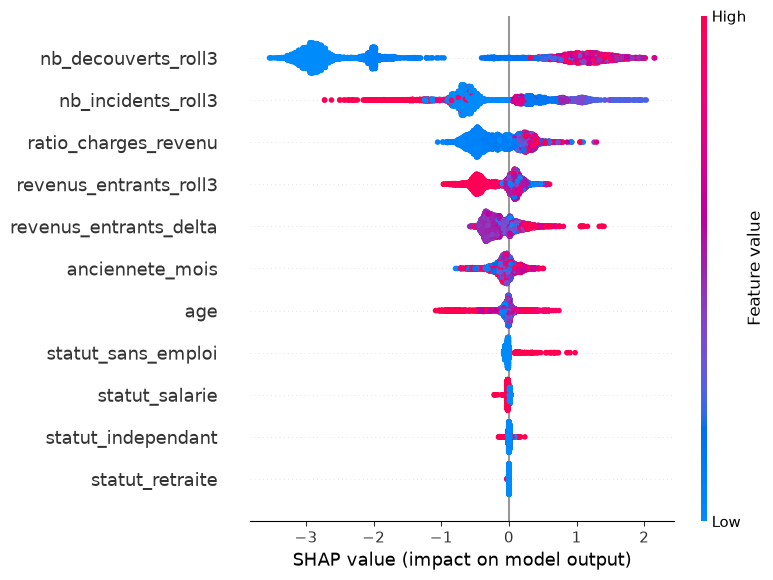

In [11]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Vue globale : quelles features pesent le plus, en moyenne, sur les predictions
shap.summary_plot(shap_values, X_test, feature_names=all_features, show=True)

Client : CLI_00016 - Mois : 14
Score reel : 1 - Score predit : 1



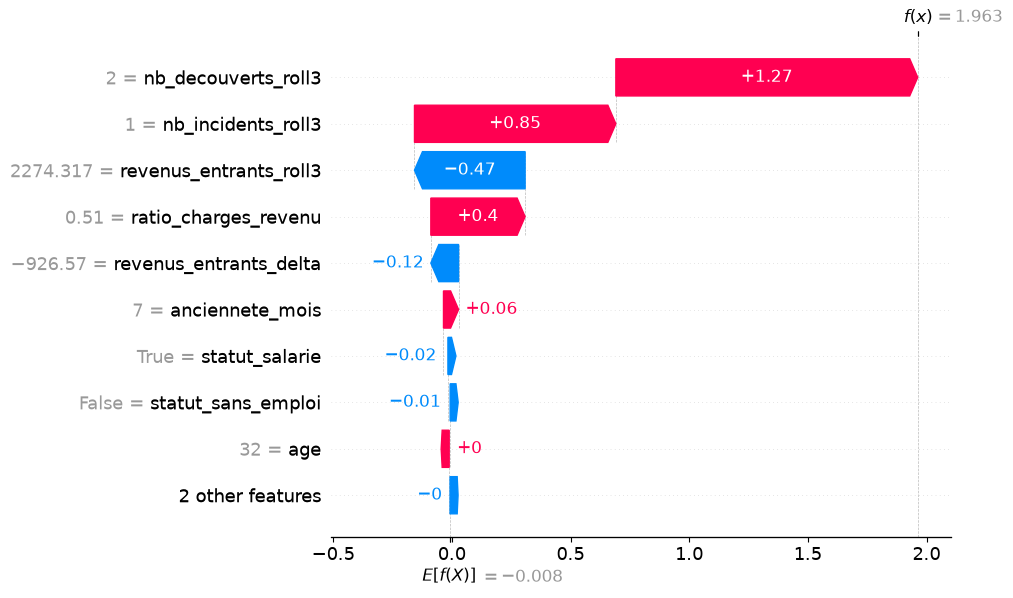

In [12]:
# On choisit un client avec un score eleve pour un exemple parlant
idx = y_pred_xgb.argmax() if y_pred_xgb.sum() > 0 else 0
# Plus utile : prendre un vrai positif bien detecte
import numpy as np
candidats = np.where((y_test.values == 1) & (y_pred_xgb == 1))[0]
idx = candidats[0]

print("Client :", test_encoded.iloc[idx]["client_id"], "- Mois :", test_encoded.iloc[idx]["mois"])
print("Score reel :", y_test.iloc[idx], "- Score predit :", y_pred_xgb[idx])
print()

shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx],
    feature_names=all_features
))